In [1]:
# 更新履歴
## 2026/02/25 複数のhdfファイルを読み込めるようにしました。
## 2026/02/12 作成

# 基本モジュール
import sys, os
from IPython.display import display, HTML, clear_output, update_display, Image
from tqdm import tqdm
import pyperclip
import json
from typing import Optional, Union

# データ分析用
import numpy as np
import pandas as pd
import h5py

# グラフ描画用
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.express as px
import plotly.graph_objects as go
import PIL.Image as im

# XRDk切り開き用（不要かも）
import pyFAI

# 自作モジュール
sys.path.append(r"C:\Users\okaza\pythonenv")
from modules.Mytools.Tools import h5_tree, dict_tree, his2array, print_fileinfo, simple_progress_bar
from modules.peakfit import peakfit
import modules.Mytools.Settings

# 初期パラメーター
cachedir = os.path.join(os.getcwd(), ".cache")
os.makedirs(cachedir, exist_ok=True)
print("cache: " + os.path.abspath(cachedir))

cache: c:\Users\okaza\Documents\Documents\fpd\create_hdfdata\1Dprofile\.cache


## 目的

peakfit_asym_1Dprofileで出力したデータを可視化する。  
csvに保存する

## データ取得

In [39]:
# フィッティング結果が格納してあるjsonファイル
number = 15
jsonfile = r"C:\Users\okaza\Documents\Documents\fpd\create_hdfdata\1Dprofile\.cache\fitres.json"

# 1D XRDが格納してあるhdfファイル
hdf_1d = r"D:\DATA\SPring-8-2025-Nov\Analysis\integrated1d_run3\UODE32_0020_integrate1d.hdf"
# hdf_dir = r"D:\DATA\SPring-8-2025-Nov\Analysis\integrated1d_run3"
# hdf_1d = [os.path.join(hdf_dir, file) for file in os.listdir(hdf_dir)][:-3]
# print(json.dumps(hdf_1d, indent = 4))

In [42]:
# ファイルを読み込んで、plotlyで出力する
def animation(jsonfile: str,
              hdf: Union[str, list[str]],
              ) -> None:

    # hdfデータ読み込み
    ity = []
    if type(hdf) == str:
        with h5py.File(hdf, mode = "r") as f:
            tth = np.array(f["rad"][()]) # type: ignore
            for i in range(len(list(f["integrated"].keys()))): # type: ignore
                ity.append(f["integrated/frame = {}".format(i)][()]) # type: ignore
    elif type(hdf) == list:
        for file in hdf:
            with h5py.File(file, mode = "r") as f:
                tth = np.array(f["rad"][()]) # type: ignore
                for i in range(len(list(f["integrated"].keys()))): # type: ignore
                    ity.append(f["integrated/frame = {}".format(i)][()]) # type: ignore
    ity = np.vstack(ity)[:599]

    # jsonデータ読み込み
    with open(jsonfile, mode = "r") as f:
        d = json.load(f)

    # インスタント化
    pf = peakfit()
    if d["func"] == "asympsdVoigt":
        fitfunc = pf.asympsdVoigt
    if d["func"] == "psdVoigt":
        fitfunc = pf.psdVoigt
    func = (lambda x, params: fitfunc(x=x, params = params) + pf.background(x = x, params = params))
    
    # figure作成
    if True:

        # インスタント化
        fig = go.Figure()
        trace_indices = dict()

        # 一枚目作成
        ## 生データ
        raw_anim = go.Scatter(
            x = tth,
            y = ity[0],
            mode = "lines",
            # marker = dict(
            #     color = "#1f77b4",
            #     size = 3,
            #     symbol = "circle"
            # ),
            line = dict(
                color = "#1f77b4",
                width = 1,
            ),
            name = "Raw",
        )
        fig.add_trace(raw_anim)
        trace_indices["raw_anim"] = len(fig.data) -1  # type: ignore
        
        ## フィッティング結果
        xs = np.linspace(*d["fitres"]["frame = 0"]["range"], 100) # type: ignore
        ys = func(x = xs, params = d["fitres"]["frame = 0"]["res"]["params"])
        fit_anim = go.Scatter(
            x = xs,
            y = ys,
            mode = "lines",
            line = dict(
                color = "#ff770e",
                width = 1.5,
            ),
            name = "Fit",
            visible = True
        )
        fig.add_trace(fit_anim)
        trace_indices["fit_anim"] = len(fig.data)-1 # type: ignore

        # アニメーションフレームを作成
        frame_list = []
        for k in range(ity.shape[0]):
            xs = np.linspace(*d["fitres"]["frame = {}".format(k)]["range"], 100) # type: ignore
            ys = func(x = xs, params = d["fitres"]["frame = {}".format(k)]["res"]["params"])
            frame_list.append(go.Frame(
                data = [
                    go.Scatter(
                        y = ity[k],
                    ),
                    go.Scatter(
                        x = xs,
                        y = ys,
                    )
                ],
                name = str(k),
                traces = [trace_indices["raw_anim"], trace_indices["fit_anim"]]
            ))
        fig.frames = frame_list

        # フレーム変更用のボタンとスライダー
        updatemenus_frame = dict(
            type='buttons',
            direction = 'left', # 横並びの場合 'left', 縦並びの場合 'down'
            showactive=False,
            active = -1,
            y=0,
            x=0,
            xanchor='left',
            yanchor='top',
            pad=dict(t=65, r=0),
            buttons=[
                dict(
                    label='▶︎',
                    method='animate',
                    args=[
                        None,
                        dict(
                            frame=dict(
                                duration=50,
                                redraw=True
                            ),
                            fromcurrent=True,
                            mode='immediate',
                            transition=dict(duration=0)
                        )
                    ]
                ),
                dict(
                    label='⏸',
                    method='animate',
                    args=[
                        [None],
                        dict(
                            frame=dict(
                                duration=0,
                                redraw=False
                            ),
                            mode='immediate',
                            transition=dict(duration=0)
                        )
                    ]
                )
            ],
            visible = True
        )
        slider = dict(
            steps=[dict(
                method='animate',
                args=[
                    [str(k)],
                    dict(
                        mode='immediate',
                        frame=dict(
                            duration=0,
                            redraw=True
                            ),
                        transition=dict(
                            duration=0
                        )
                    )
                ],
                label=str(k),
            ) for k in range(ity.shape[0])],
            ticklen = 0,
            minorticklen = 0,
            active=0,
            y=0,
            x=0, # スライダーの開始位置
            len=1, # スライダーの長さ
            xanchor='left',
            yanchor='top',
            pad=dict(
                b=10,
                t=50,
                l=100
            ),
            currentvalue=dict(
                prefix='Frame = ',
                visible=True,
                xanchor='left'
            ),
            visible = True,
        )

        fig.update_layout(
            title = dict(
                text = os.path.splitext(os.path.basename(hdf))[0] if type(hdf) == str else None,
                font = dict(
                    size = 26,
                    color = "#777777"
                ),
                x = 0.05,
                y = 0.95,
                xanchor = "left",
                yanchor = "top",
            ),
            xaxis = {
                'title': "2theta [deg.]",
                "linecolor": "#000000",
                "linewidth": 1,
                'ticks': "inside",
                "tickcolor": "#000000",
                "tickwidth": 1,
                "ticklen": 5,
                'mirror': True,
            },
            yaxis = {
                'title': "Frame",
                "linecolor": "#000000",
                "linewidth": 1,
                'ticks': "inside",
                "tickcolor": "#000000",
                "tickwidth": 1,
                "ticklen": 5,
                'mirror': True,
            },
            plot_bgcolor = '#ffffff',
            updatemenus = [
                updatemenus_frame,
            ],
            sliders = [slider],
            showlegend = False,
            legend = dict(
                bordercolor = "#000000",
                orientation = "h",
                yanchor = "bottom",
                y = 1,
                bgcolor = "rgba(255,255,255,0)",
                xanchor = "center",
                x = 0.5
            ),
            width = 800,
            height = 600,
        )

        fig.show()

    return
animation(jsonfile = jsonfile, hdf = hdf_1d)
del animation


## csv出力

Save: c:\Users\okaza\Documents\Documents\fpd\create_hdfdata\1Dprofile\.cache\fitres.csv


Save: c:\Users\okaza\Documents\Documents\fpd\create_hdfdata\1Dprofile\.cache\fitres.png


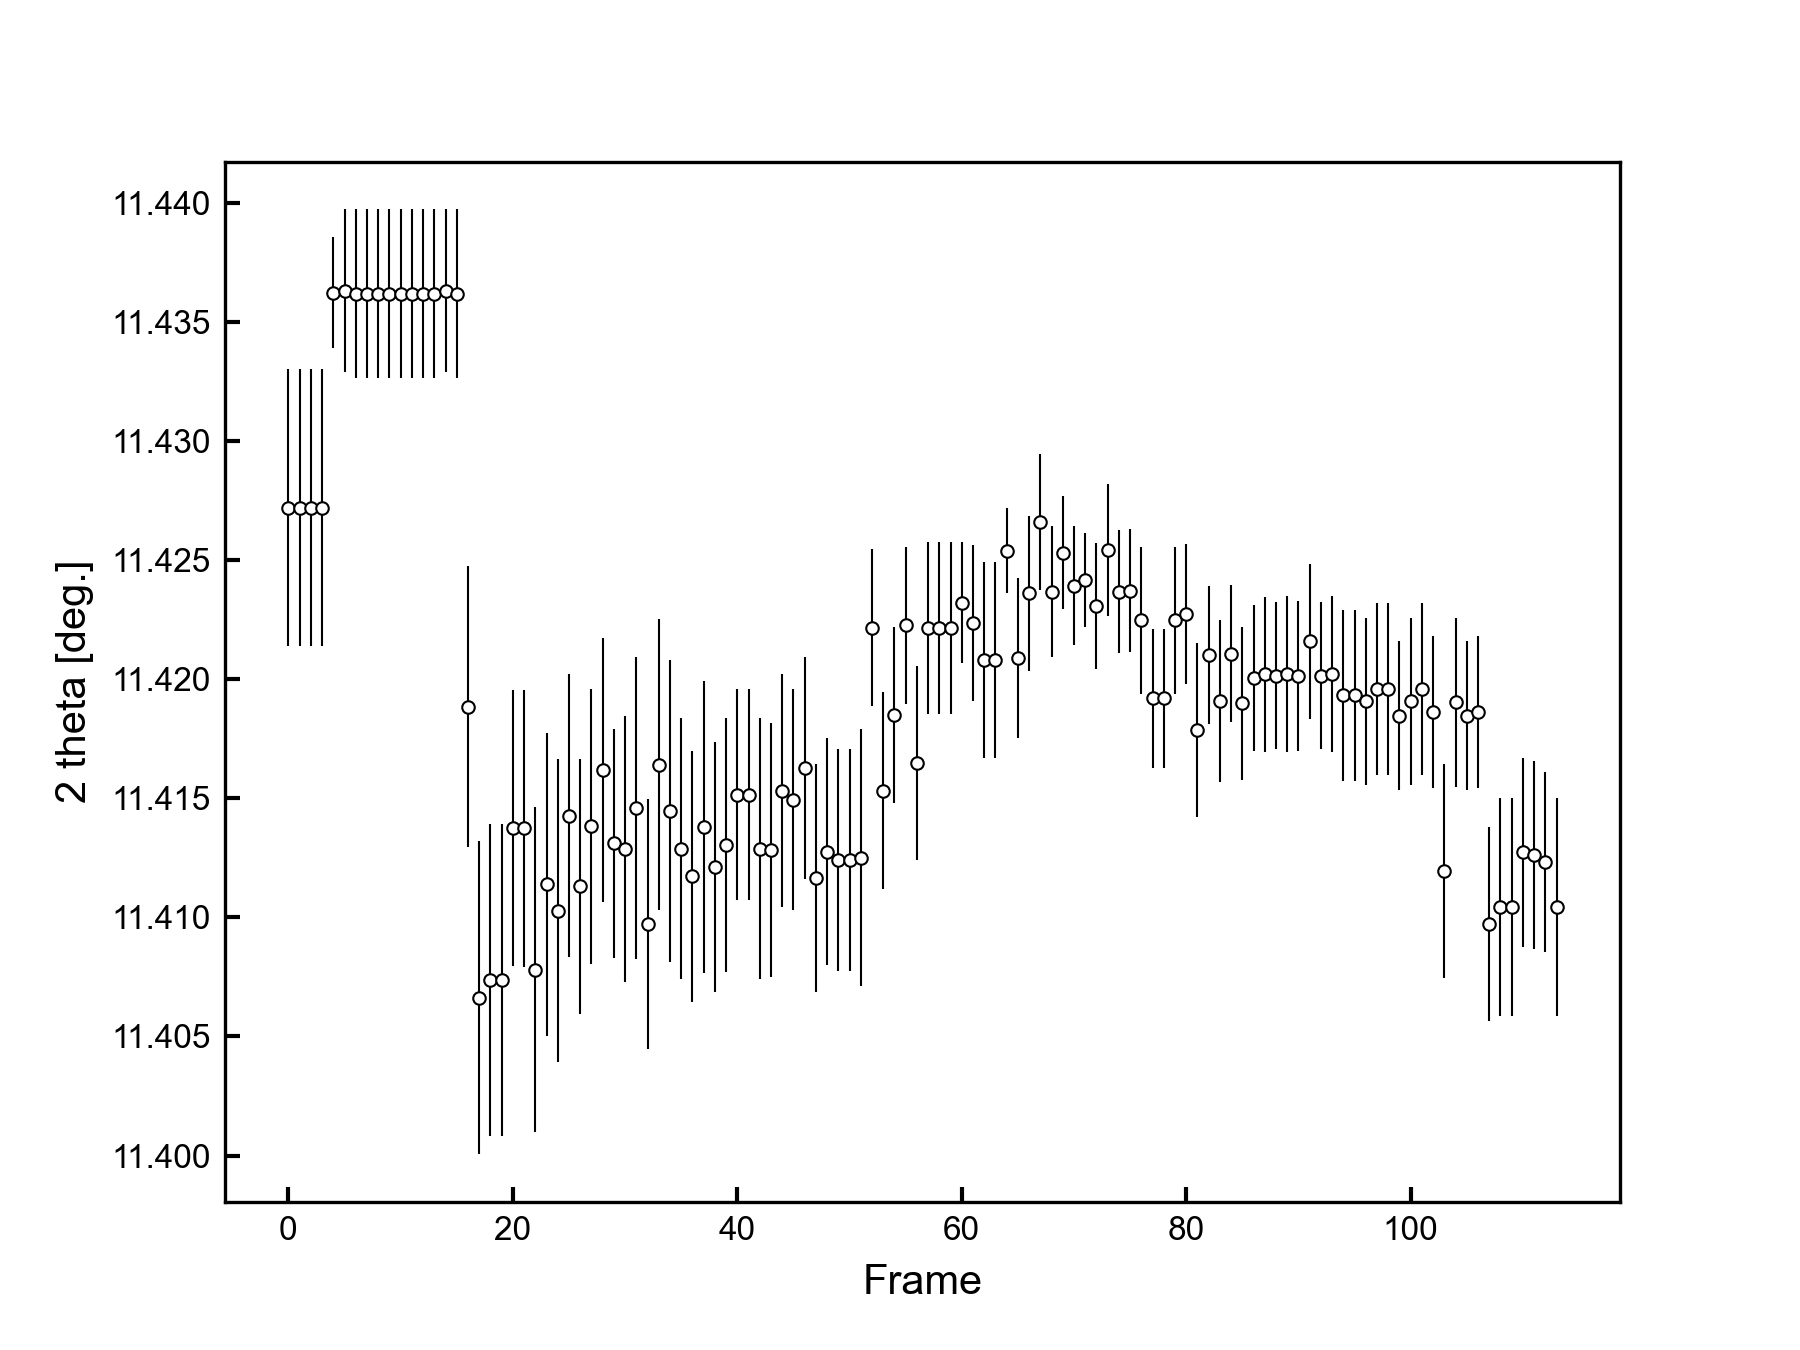

In [43]:
# figureとcsvを作成します
def makecsv(jsonfile: str,
            hdf: Union[str, list[str]],
            ) -> None:

    # データ読み込み
    ity = []
    if type(hdf) == str:
        with h5py.File(hdf, mode = "r") as f:
            tth = np.array(f["rad"][()]) # type: ignore
            for i in range(len(list(f["integrated"].keys()))): # type: ignore
                ity.append(f["integrated/frame = {}".format(i)][()]) # type: ignore
    elif type(hdf) == list:
        for file in hdf:
            with h5py.File(file, mode = "r") as f:
                tth = np.array(f["rad"][()]) # type: ignore
                for i in range(len(list(f["integrated"].keys()))): # type: ignore
                    ity.append(f["integrated/frame = {}".format(i)][()]) # type: ignore
    ity = np.vstack(ity)
    with open(jsonfile, mode = "r") as f:
        d = json.load(f)
    
    # フレーム
    n_frame = len(d["fitres"].keys())
    frame = np.arange(n_frame)

    # for文用の変数
    pos = []
    err = []
    pf = peakfit()
    sns = []
    if d["func"] == "asympsdVoigt":
        fitfunc = pf.asympsdVoigt
        areafunc = pf.asympsdVoigt_area
    if d["func"] == "psdVoigt":
        fitfunc = pf.psdVoigt
        areafunc = pf.psdVoigt_area

    # 位置とエラーを取得
    for i in frame:

        # データ取得
        res = d["fitres"]["frame = {}".format(i)]["res"]

        # 位置
        pos.append(res["params"]["center"])

        # フィッティングエラー
        err_fit = res["err"]["center"]

        # バックグラウンド
        tth_range = d["fitres"]["frame = {}".format(i)]["range"]
        tth_mask = (tth > tth_range[0]) * (tth < tth_range[1])
        y_obs = ity[i][tth_mask]
        y_opt = fitfunc(x = tth[tth_mask], params = res["params"]) + pf.background(x = tth[tth_mask], params = res["params"])
        bg = np.sqrt(np.sum(np.square(y_opt - y_obs)))

        # ピーク強度
        area = areafunc(params = res["params"])/(tth[1]-tth[0])

        # シグナルノイズ比
        sn = area / np.sqrt(area + bg)
        sns.append(sn)

        # ピークエラー
        if d["func"] == "asympsdVoigt":
            fwhm = np.mean([res["params"][side]["fwhm"] for side in ["left", "right"]])
        if d["func"] == "psdVoigt":
            fwhm = np.array(res["params"]["fwhm"])
        err_peakrange = fwhm / sn

        # エラー算出
        err.append(np.sqrt(np.square(err_fit) + np.square(err_peakrange)))

    # plt.plot(sns)
    # return

    # csv保存
    df = pd.DataFrame(np.array([pos,err]).T, index = frame)
    df.columns = ["2 theta [deg.]", "err [deg.]"]
    csvfile = os.path.join(cachedir, "fitres.csv")
    df.to_csv(csvfile)
    print("Save: "+ os.path.abspath(csvfile))

    if True: # plotly
        fig = go.Figure()
        
        errplot = go.Scatter(
            x=frame,
            y=pos,
            error_y=dict(
                type='data',       # データごとに値を指定するモード
                array=err, # エラーバーの長さのリスト
                visible=True,      # 表示をオンにする
                color='#000000',       # エラーバーの色
                thickness=0.5,     # エラーバーの太さ
                width=0            # 先端の横棒（キャップ）の幅
            ),
            mode='markers', # 点のみ表示（線をつなぐ場合は 'lines+markers'）
            marker = {
                'symbol': "circle",
                'size': 3,
                'color': "#000000"
            }
        )
        fig.add_trace(errplot)

        fig.update_layout(
            title = dict(
                text = os.path.splitext(os.path.basename(hdf))[0] if type(hdf) == str else None,
                font = dict(
                    size = 26,
                    color = "#777777"
                ),
                x = 0.05,
                y = 0.95,
                xanchor = "left",
                yanchor = "top",
            ),
            xaxis = {
                'title': "Frame",
                "linecolor": "#000000",
                "linewidth": 1,
                'ticks': "inside",
                "tickcolor": "#000000",
                "tickwidth": 1,
                "ticklen": 5,
                'mirror': True,
            },
            yaxis = {
                'title': "2 theta [deg.]",
                "linecolor": "#000000",
                "linewidth": 1,
                'ticks': "inside",
                "tickcolor": "#000000",
                "tickwidth": 1,
                "ticklen": 5,
                'mirror': True,
            },
            plot_bgcolor = '#ffffff',
            showlegend = False,
            legend = dict(
                bordercolor = "#000000",
                orientation = "h",
                yanchor = "bottom",
                y = 1,
                bgcolor = "rgba(255,255,255,0)",
                xanchor = "center",
                x = 0.5
            ),
            width = 800,
            height = 600,
        )

        fig.show()
    
    if True: # matplotlib
        fig, ax = plt.subplots()
        fig.set_size_inches(6,4.5)

        ax.errorbar(
            x = frame,
            y = pos,
            yerr = err,
            lw = 0,
            fmt = "o",
            ms = 3,
            c = "0",
            mfc = "1",
            elinewidth=0.5,
            mew = 0.5
        )
        ax.set_xlabel("Frame", fontsize = 10)
        ax.set_ylabel("2 theta [deg.]", fontsize = 10)


        pngfile = os.path.join(cachedir, "fitres.png")
        plt.savefig(pngfile, dpi = 300)
        plt.close()
        print("Save: " + os.path.abspath(pngfile))
        display(Image(pngfile, width = 600))
    
    return
makecsv(jsonfile=jsonfile, hdf = hdf_1d)
del makecsv